<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/Applied_QML_Rehber_Secim_Araci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Applied QML: Kuantum Makine Öğrenmesi
Uygulama Rehberi
Eğitmen: Joseph Volkan Özcan

Merhaba, bu doküman Applied QML dersi kapsamında bir kuantum makine öğrenmesi projesinin
uçtan uca nasıl geliştirileceğini aşamalar halinde göstermek için hazırlanmıştır. Bu rehber öğrenme
sürecini sadeleştirmek adına sadece Python ve IBM Qiskit kullanılarak tasarlanmıştır.

AŞAMA 1: Kuantum Projesinin Tanımının Yapılması ve Uygun Cihaz/Algoritma Seçimi

Projenin başlangıcında amacın net bir şekilde belirlenmesi gerekir. Çözülmek istenen problem bir
**Sınıflandırma**, **Regresyon** veya **Optimizasyon** problemi olabilir.

Bu aşamada aşağıdaki interaktif seçim aracını kullanarak:
1. Probleminizi tanımlayın (tip, özellik sayısı, veri boyutu, veri tipi)
2. Sistem size **uygun data encoding yöntemini** ve **ihtiyaç duyulan kübit sayısını** hesaplasın
3. Aynı anda **uygun kuantum algoritmalarını** ve **çalıştırılacak cihazları** (simülatör / gerçek IBM Quantum) önerilsin

> **Önemli Not (NISQ Dönemi):** Günümüz kuantum bilgisayarları gürültülü ve sınırlı kübit sayısına sahiptir.
> Yüksek boyutlu verilerde mutlaka PCA gibi boyut indirgeme yöntemleri kullanılmalı,
> geliştirme aşamasında mutlaka **simülatör** ile başlanmalıdır.
>
> Encoding seçimi, hem kübit ihtiyacını hem de devre derinliğini doğrudan etkiler.
> Angle Encoding / ZZFeatureMap pratik ve stabil iken, Amplitude Encoding çok daha az kübit kullanır ama hazırlama maliyeti yüksektir.


In [ ]:
# ============================================================
# AŞAMA 1 - İnteraktif Problem Tanımı + Cihaz & Algoritma Seçim Aracı
# + Veri Tipi / Boyuta Göre Encoding Önerisi ve Qubit Hesabı
# Colab uyumlu (ipywidgets)
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import math
import numpy as np

# ---------- Widget'lar ----------
problem_type = widgets.Dropdown(
    options=[
        ("Sınıflandırma (Classification)", "classification"),
        ("Regresyon (Regression)", "regression"),
        ("Optimizasyon (Optimization)", "optimization")
    ],
    value="classification",
    description="Problem Tipi:",
    style={"description_width": "130px"},
    layout=widgets.Layout(width="450px")
)

n_features = widgets.IntSlider(
    value=4,
    min=2,
    max=30,
    step=1,
    description="Özellik Sayısı:",
    style={"description_width": "130px"},
    continuous_update=False
)

n_samples = widgets.IntSlider(
    value=200,
    min=50,
    max=5000,
    step=50,
    description="Veri Boyutu:",
    style={"description_width": "130px"},
    continuous_update=False
)

data_type = widgets.Dropdown(
    options=[
        ("Sürekli (Continuous)", "continuous"),
        ("Kategorik (Categorical)", "categorical"),
        ("Karışık (Mixed)", "mixed")
    ],
    value="continuous",
    description="Veri Tipi:",
    style={"description_width": "130px"},
    layout=widgets.Layout(width="450px")
)

priority = widgets.Dropdown(
    options=[
        ("Hızlı prototip / Eğitim (Simülatör öncelikli)", "prototype"),
        ("Gerçek donanım denemesi (IBM Quantum)", "hardware"),
        ("Yüksek doğruluk / Derin devre (Simülatör + hata azaltma)", "accuracy")
    ],
    value="prototype",
    description="Öncelik:",
    style={"description_width": "130px"},
    layout=widgets.Layout(width="520px")
)

run_button = widgets.Button(
    description="Encoding + Qubit + Algoritma & Cihaz Öner",
    button_style="success",
    icon="check",
    layout=widgets.Layout(width="380px", height="42px")
)

output_area = widgets.Output()

# ---------- Yardımcı: Encoding & Qubit Hesap Motoru ----------
def compute_encoding_and_qubits(features, samples, dtype):
    """
    Veri tipi ve boyutuna göre encoding yöntemlerini önerir
    ve her yöntem için ihtiyaç duyulan qubit sayısını hesaplar.
    """
    results = {
        "primary": None,          # (isim, qubit, açıklama, qiskit_kod)
        "alternatives": [],       # liste of (isim, qubit, açıklama)
        "pca_recommended": features > 8,
        "pca_target": min(6, max(2, features // 2)) if features > 8 else features,
        "warnings": []
    }

    # ----- Temel formüller -----
    # Angle Encoding / ZZFeatureMap: 1 qubit / özellik
    angle_qubits = features

    # Amplitude Encoding: ceil(log2(n_features)) — vektör boyutu 2^n olmalı
    amp_qubits = math.ceil(math.log2(max(features, 2)))
    # Amplitude için padding notu
    amp_padded = 2 ** amp_qubits

    # Basis Encoding (kaba tahmin): her özellik için ~4-8 bit varsayalım (sürekli → quantize)
    # Kategorik için one-hot sonrası boyut artar
    basis_qubits_est = features * 4   # kaba üst sınır

    # ----- Veri tipine göre birincil öneri -----
    if dtype == "continuous":
        # Sürekli veriler → Angle Encoding veya ZZFeatureMap en pratik
        if features <= 8:
            results["primary"] = (
                "Angle Encoding + ZZFeatureMap",
                angle_qubits,
                "Her özellik bir kübitin dönme açısına (RX/RY/RZ) yazılır. "
                "ZZFeatureMap ile özellikler arası etkileşim (entanglement) eklenir. "
                "NISQ için en yaygın ve stabil yöntem.",
                "zz_feature_map(feature_dimension=n, reps=2, entanglement='linear')"
            )
            results["alternatives"].append((
                "PauliFeatureMap",
                angle_qubits,
                "ZZFeatureMap'e benzer, farklı Pauli operatörleri kullanır. Daha zengin kernel üretebilir."
            ))
            results["alternatives"].append((
                "Amplitude Encoding",
                amp_qubits,
                f"Sadece ~{amp_qubits} kübit kullanır (2^{amp_qubits} = {amp_padded} boyuta pad edilir). "
                "Ancak state preparation maliyeti yüksek, NISQ'te zordur. Büyük özellik setlerinde düşünülebilir."
            ))
        else:
            # Yüksek özellik → önce PCA, sonra Angle
            results["primary"] = (
                "PCA → Angle Encoding + ZZFeatureMap",
                results["pca_target"],
                f"Özellik sayısı ({features}) yüksek. Önce PCA ile {results['pca_target']} boyuta indirin, "
                "ardından Angle Encoding / ZZFeatureMap uygulayın. Doğrudan 20+ kübit NISQ'te pratik değildir.",
                "PCA(n_components=k) + zz_feature_map(feature_dimension=k, reps=2)"
            )
            results["alternatives"].append((
                "Amplitude Encoding (PCA sonrası veya doğrudan)",
                amp_qubits,
                f"Doğrudan uygulanırsa sadece {amp_qubits} kübit gerekir. Ancak hazırlama devresi çok derin olur."
            ))
            results["warnings"].append(
                f"Özellik sayısı {features} > 8 → mutlaka boyut indirgeme (PCA) yapın."
            )

    elif dtype == "categorical":
        # Kategorik → önce One-Hot, sonra Angle veya Basis
        results["primary"] = (
            "One-Hot Encoding (klasik) → Angle Encoding / Basis Encoding",
            angle_qubits,   # one-hot sonrası özellik sayısı değişir; kullanıcı bilgilendirilir
            "Kategorik değerler kuantum devresine doğrudan yazılamaz. "
            "Önce pandas.get_dummies / OneHotEncoder ile 0-1 vektörüne çevirin. "
            "Ardından ortaya çıkan sürekli (0/1) özellikleri Angle Encoding ile kübitlere yerleştirin. "
            "Alternatif: her kategori için Basis Encoding (daha az kübit ama daha az esnek).",
            "pd.get_dummies(...) → zz_feature_map / Angle Encoding"
        )
        results["alternatives"].append((
            "Basis Encoding (doğrudan)",
            "değişken (kategori sayısı log2)",
            "Her kategorik değişkenin alabileceği değer sayısı 2^k ise k kübit yeterlidir. "
            "Küçük kardinaliteli kategoriler için uygundur."
        ))
        results["warnings"].append(
            "One-Hot Encoding özellik sayısını (dolayısıyla kübit ihtiyacını) artırabilir. "
            "Kardinalitesi yüksek sütunlarda dikkatli olun veya hedef encoding kullanın."
        )
        results["warnings"].append(
            "Kategorik veri için notebook'taki Aşama 3 örnek kodunu (pd.get_dummies) kullanın."
        )

    else:  # mixed
        results["primary"] = (
            "Hibrit: Kategorik → One-Hot + Sürekli → Angle/ZZFeatureMap",
            angle_qubits,
            "Kategorik sütunları One-Hot ile sayısallaştırın, sürekli sütunları olduğu gibi bırakın. "
            "Birleşik özellik vektörünü Angle Encoding veya ZZFeatureMap ile kodlayın. "
            "Toplam özellik sayısı artacağı için PCA ihtimalini göz önünde bulundurun.",
            "One-Hot (kategorik) + StandardScaler + (opsiyonel PCA) + zz_feature_map"
        )
        results["alternatives"].append((
            "Ayrı encoding + feature concatenation",
            "değişken",
            "Kategorik ve sürekli özellikleri farklı feature map'lerle kodlayıp devreleri birleştirmek mümkün "
            "ama daha karmaşık devre ve daha fazla kübit gerektirir."
        ))
        if features > 6:
            results["pca_recommended"] = True
            results["warnings"].append(
                "Karışık veri + orta/yüksek özellik sayısı → PCA ile 4-6 boyuta indirmeyi şiddetle öneririz."
            )

    # Veri boyutu (n_samples) etkisi — encoding'i değil, kernel/shot maliyetini etkiler
    if samples > 1000 and dtype != "optimization":
        results["warnings"].append(
            f"Veri boyutu ({samples}) büyük. Kernel tabanlı yöntemlerde (QSVM) her çift için devre çalıştırılır → "
            "hesaplama maliyeti O(n²) artar. Mümkünse örnekleme veya mini-batch düşünün."
        )
    if samples < 80:
        results["warnings"].append(
            "Veri boyutu çok küçük. Model genellemesi zayıf olabilir; cross-validation ve dikkatli regularization kullanın."
        )

    return results


# ---------- Ana Öneri Motoru ----------
def get_recommendations(prob, features, samples, dtype, prio):
    recs = {
        "algorithms": [],
        "devices": [],
        "notes": [],
        "encoding_info": None,   # compute_encoding_and_qubits sonucu
        "pca_required": features > 8
    }

    # 1) Encoding + Qubit hesabı
    recs["encoding_info"] = compute_encoding_and_qubits(features, samples, dtype)

    # 2) Algoritma önerileri
    if prob == "classification":
        recs["algorithms"] = [
            ("FidelityQuantumKernel + QSVM", "Küçük-orta veri setleri, kernel tabanlı sınıflandırma. Bu notebook'un ana yöntemi."),
            ("Variational Quantum Classifier (VQC)", "RealAmplitudes ansatz ile eğitilebilir sınıflandırıcı."),
            ("Quantum Neural Network (EstimatorQNN / SamplerQNN)", "Daha esnek, katmanlı mimariler için.")
        ]
        if features <= 6 and samples <= 500:
            recs["algorithms"].insert(0, (
                "QSVM (Quantum Support Vector Machine)",
                "Küçük özellik sayısı için en temiz ve yorumlanabilir seçenek."
            ))
    elif prob == "regression":
        recs["algorithms"] = [
            ("Variational Quantum Regressor", "VQC benzeri varyasyonel regresyon."),
            ("Quantum Kernel Ridge Regression", "Kernel yöntemlerinin regresyona uyarlanmış hali."),
            ("EstimatorQNN tabanlı regresyon", "Beklenti değeri üzerinden sürekli çıktı.")
        ]
    else:  # optimization
        recs["algorithms"] = [
            ("QAOA (Quantum Approximate Optimization Algorithm)", "Kombinatoryal optimizasyon için standart yöntem."),
            ("VQE (Variational Quantum Eigensolver)", "Hamiltonian minimizasyonu gerektiren problemler."),
            ("Grover / Amplitude Amplification", "Yapılandırılmış arama problemleri (ileri seviye).")
        ]

    # 3) Cihaz önerileri
    effective_qubits = recs["encoding_info"]["primary"][1]
    if isinstance(effective_qubits, str):
        effective_qubits = features  # fallback

    if features > 12 or samples > 2000:
        recs["notes"].append("Yüksek özellik/veri boyutu → mutlaka PCA ile 4-8 boyuta indirgeme yapın.")
        recs["pca_required"] = True

    if prio == "prototype":
        recs["devices"] = [
            ("AerSimulator / StatevectorSampler (qiskit-aer)", "En hızlı, gürültüsüz, geliştirme için ideal. Notebook varsayılanı."),
            ("Qiskit Runtime Simulator", "Bulut simülasyonu, gerçek donanım API deneyimi.")
        ]
        recs["notes"].append("Önce simülatörde modeli tamamen doğrulayın, sonra gerçek donanıma geçin.")
    elif prio == "hardware":
        if effective_qubits <= 5:
            recs["devices"] = [
                ("IBM Quantum küçük gerçek backend'ler", "≤5 kübit için uygun gerçek cihazlar."),
                ("AerSimulator (ön test)", "Gerçek cihaza göndermeden önce mutlaka simülatörde doğrulayın.")
            ]
        elif effective_qubits <= 10:
            recs["devices"] = [
                ("IBM Quantum 127+ kübit sistemler (transpilation + error mitigation)", "6-10 kübit için PCA sonrası gerçek donanım denenebilir."),
                ("Qiskit Runtime + SamplerV2 / EstimatorV2", "Modern primitives ile çalıştırma.")
            ]
            recs["notes"].append("Gerçek donanımda devre derinliğini düşük tutun (reps=1-2). ResilienceLevel kullanın.")
        else:
            recs["devices"] = [
                ("Önce PCA → 4-6 özellik, sonra gerçek donanım", "12+ kübit doğrudan pratik değildir."),
                ("AerSimulator + noise model", "Gerçek cihaz gürültüsünü taklit ederek geliştirin.")
            ]
            recs["notes"].append("Yüksek kübit ihtiyacı nedeniyle şu an simülatör + PCA zorunludur.")
    else:  # accuracy
        recs["devices"] = [
            ("StatevectorSampler (exact)", "Gürültüsüz, matematiksel olarak doğru sonuçlar."),
            ("AerSimulator (shot-based) + yüksek shot (8192+)", "İstatistiksel kararlılık için."),
            ("Gerçek donanım + Error Mitigation (ZNE, PEC)", "Son aşamada doğruluk artırmak için.")
        ]
        recs["notes"].append("Yüksek doğruluk için shot sayısını artırın ve hata azaltma teknikleri uygulayın.")

    # Genel notlar
    if samples < 100:
        recs["notes"].append("Veri boyutu çok küçük → overfitting riski; cross-validation kullanın.")
    if dtype == "categorical":
        recs["notes"].append("Kategorik veriler doğrudan işlenemez → One-Hot Encoding zorunlu.")

    return recs


# ---------- Buton callback ----------
def on_button_clicked(b):
    with output_area:
        clear_output()
        recs = get_recommendations(
            problem_type.value,
            n_features.value,
            n_samples.value,
            data_type.value,
            priority.value
        )
        enc = recs["encoding_info"]

        display(HTML("<h3 style='color:#1a73e8; margin-bottom:8px;'>🔍 Öneri Sonuçları</h3>"))

        # Özet
        print(f"Problem Tipi     : {problem_type.label}")
        print(f"Özellik Sayısı   : {n_features.value}")
        print(f"Veri Boyutu      : {n_samples.value}")
        print(f"Veri Tipi        : {data_type.label}")
        print(f"Öncelik          : {priority.label}")
        print("=" * 70)

        # ========== ENCODING + QUBIT HESABI (yeni detaylı bölüm) ==========
        display(HTML(
            "<div style='background:#e8f0fe; padding:12px 16px; border-radius:8px; margin:12px 0;'>"
            "<h4 style='margin:0 0 8px 0; color:#174ea6;'>📐 Veri Encoding Yöntemi & İhtiyaç Duyulan Qubit Hesabı</h4>"
            "</div>"
        ))

        name, qubits, desc, qiskit_hint = enc["primary"]
        print(f"▶ Birincil Öneri : {name}")
        print(f"   Gerekli Qubit : {qubits}")
        print(f"   Açıklama      : {desc}")
        print(f"   Qiskit İpucu  : {qiskit_hint}")
        print()

        # Alternatifler
        if enc["alternatives"]:
            display(HTML("<b>🔄 Alternatif Encoding Yöntemleri:</b>"))
            for i, (alt_name, alt_q, alt_desc) in enumerate(enc["alternatives"], 1):
                print(f"   {i}. {alt_name}")
                print(f"      Qubit ≈ {alt_q}")
                print(f"      → {alt_desc}")
            print()

        # Qubit karşılaştırma tablosu (özet)
        display(HTML("<b>📊 Hızlı Qubit Karşılaştırması (mevcut özellik sayısına göre):</b>"))
        f = n_features.value
        angle_q = f
        amp_q = math.ceil(math.log2(max(f, 2)))
        print(f"   • Angle Encoding / ZZFeatureMap  →  {angle_q} kübit  (1 özellik = 1 kübit)")
        print(f"   • Amplitude Encoding             →  {amp_q} kübit  (ceil(log2({f})) , 2^{amp_q} boyuta pad)")
        print(f"   • Basis Encoding (kaba tahmin)   →  ~{f*3}-{f*8} kübit (değer aralığına bağlı)")
        if enc["pca_recommended"]:
            print(f"   • PCA sonrası (önerilen {enc['pca_target']} özellik) →  {enc['pca_target']} kübit (Angle ile)")
        print()

        # PCA uyarısı
        if enc["pca_recommended"] or recs["pca_required"]:
            display(HTML(
                "<div style='background:#fff3cd; padding:10px 14px; border-radius:6px; margin:8px 0;'>"
                f"<b>⚠️ Boyut İndirgeme (PCA) Önerilir:</b> Özellik sayısı yüksek ({n_features.value}). "
                f"Aşama 3'teki PCA adımı ile <b>{enc['pca_target']}</b> boyuta indirmeniz "
                "hem kübit sayısını hem de gürültüyü önemli ölçüde azaltır."
                "</div>"
            ))
            print()

        # Encoding uyarıları
        if enc["warnings"]:
            display(HTML("<b>⚠️ Encoding ile ilgili uyarılar:</b>"))
            for w in enc["warnings"]:
                print(f"   • {w}")
            print()

        print("=" * 70)

        # ========== ALGORİTMALAR ==========
        display(HTML("<b>🧠 Önerilen Kuantum Algoritmaları:</b>"))
        for i, (name, desc) in enumerate(recs["algorithms"], 1):
            print(f"   {i}. {name}")
            print(f"      → {desc}")
        print()

        # ========== CİHAZLAR ==========
        display(HTML("<b>💻 Önerilen Cihazlar / Çalıştırma Ortamları:</b>"))
        for i, (name, desc) in enumerate(recs["devices"], 1):
            print(f"   {i}. {name}")
            print(f"      → {desc}")
        print()

        # ========== GENEL NOTLAR ==========
        if recs["notes"]:
            display(HTML("<b>📝 Ek Notlar:</b>"))
            for note in recs["notes"]:
                print(f"   • {note}")

        print("\n" + "=" * 70)
        display(HTML(
            "<b>➡️ Sonraki Adım:</b> Aşama 2'ye geçerek kütüphaneleri kurun. "
            "Burada önerilen özellik / kübit sayısını Aşama 3 (PCA) ve Aşama 6-7 "
            "(feature_map & ansatz) hücrelerinde kullanın."
        ))


# Bağla ve göster
run_button.on_click(on_button_clicked)

ui = widgets.VBox([
    widgets.HTML("<h3 style='margin-bottom:4px;'>🎯 Problem Tanımı + Encoding & Qubit Seçim Aracı</h3>"),
    widgets.HTML("<p style='color:#555; margin-top:0;'>Veri tipini ve boyutunu seçtiğinizde uygun <b>data encoding</b> yöntemi "
                 "ve ihtiyaç duyulan <b>kübit sayısı</b> otomatik hesaplanır.</p>"),
    problem_type,
    n_features,
    n_samples,
    data_type,
    priority,
    widgets.HTML("<br>"),
    run_button,
    output_area
])

display(ui)



Aşama 2: Kütüphane Kurulumları ve Çevresel Ayarlar

Kuantum cihazları ve veri işleme işlemleri için gerekli olan IBM Qiskit kütüphanelerinin kurulumu
yapılır.

Terminal/CMD Kurulum Komutu:
pip install qiskit qiskit-machine-learning qiskit-ibm-runtime numpy pandas
python-dotenv scikit-learn

In [ ]:
import os
from dotenv import load_dotenv
import numpy as np
!pip install qiskit qiskit-machine-learning qiskit-ibm-runtime scikit-learn numpy pandas python-dotenv
!pip install qiskit-algorithms
!pip install qiskit-aer
import pandas as pd
# Gerçek Makine erişimleri için IBM API anahtarını .env dosyasından alma
load_dotenv()
ibm_api_key = os.getenv("IBM_QUANTUM_TOKEN")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/3

Aşama 3: Veri Tipi ve Niteliklerinin (Attributes) Belirlenmesi
(Detaylandırılmış Kısım)

Bu aşama, klasik verilerin bir kuantum devresinde (Quantum Circuit) nasıl işleneceğini belirleyen
en kritik adımlardan biridir. Kuantum Makine Öğrenmesinde (QML) verinin boyutu ve tipi (sürekli
veya kategorik), kullanılacak kuantum donanımının özelliklerine göre şekillendirilmelidir.

1. Kübit Kısıtları (Qubit Constraints) ve NISQ Dönemi
Günümüz kuantum bilgisayarları NISQ (Noisy Intermediate-Scale Quantum) olarak adlandırılan
dönemdedir. Bu cihazların kübit sayısı kısıtlıdır ve kuantum devreleri derinleştikçe (gate derinliği
arttıkça) gürültü (noise) sebebiyle sonuçlar bozulmaya başlar. Qiskit'te `QuantumCircuit`
oluştururken, kullanacağınız veri setindeki her bir özellik (feature) veya nitelik, sıklıkla bir veya daha
fazla kübit gerektirir.

Veri Boyutu ve Kübit İlişkisi: Eğer 100 farklı özelliğe (kolona) sahip bir veri setiniz
varsa, standart bir Açı Kodlaması (Angle Encoding) yöntemi kullandığınızda, bunu
kuantum cihazına aktarmak için 100 kübite ihtiyacınız olacaktır. NISQ dönemi cihazları
için bu genellikle imkansız veya çok gürültülü sonuçlar doğuran bir derinlik yaratır.



2. Boyut İndirgeme (Dimensionality Reduction) ve PCA Kullanımı
Yukarıda bahsedilen kübit sınırlamaları nedeniyle, kuantum modeline girmeden önce klasik verinin
boyutunun düşürülmesi neredeyse zorunludur. Bunun için en yaygın kullanılan yöntem PCA
(Principal Component Analysis - Temel Bileşenler Analizi)'dir. PCA, klasik verideki en önemli
varyansları korurken özellik sayısını (örneğin 30 boyuttan 4 boyuta) düşürür.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Örnek: 30 özelliğe sahip bir veri setini Kuantum cihazına uygun olması için 4 özelliğe indirme
def boyut_indirgeme_uygula(X_veri):
    # Kuantum sistemler -1, 1 aralığında veya Normalize verilere daha iyi tepki verir
    # Bu yüzden önce standartlaştırma yapılır, ardından PCA ile özellik sayısı düşürülür
    pipeline = make_pipeline(StandardScaler(), PCA(n_components=4))
    X_kucultulmus = pipeline.fit_transform(X_veri)
    return X_kucultulmus

3. Sürekli (Continuous) vs. Kategorik (Categorical)

Veri Tipleri
Verinin türü, Qiskit'te hangi Encoding (Veri Kodlama) yönteminin kullanılacağını belirler.
-Sürekli Veriler (Continuous Data): Yaş, Gelir, Fiyat gibi sürekli değerlere sahip değişkenler,
kuantum kapılarının dönüş açılarına (Rotation Angles) yerleştirilmek için idealdir. Bu işlem
Qiskit'te genellikle Angle Encoding (Açı Kodlaması) veya ZZFeatureMap kullanılarak yapılır.

-Kategorik Veriler (Categorical Data): Cinsiyet, Şehir, Renk gibi kategorik verilerin kuantum
devresine aktarılmadan önce bir sayısal formata dönüştürülmesi gerekir. QML modelleri kategorik verileri işlerken zorlanabilir. Bu nedenle bu veriler öncelikle One-Hot Encoding
yöntemiyle işlenmeli, ardından kübitlere dağıtılmalıdır. Örneğin; `NeuralNetworkClassifier`
veya varyasyonlu devreler kullanılırken, ayrık/kategorik veriler Qiskit içinde özel olarak
değerlendirilmelidir.

In [ ]:
# Kategorik veriyi klasik ortamda QML'e hazırlama (One-Hot Encoding örneği)
import pandas as pd
veri_sozlugu = {'Yas': [25, 45, 30], 'Sehir': ['Ankara', 'Izmir', 'Ankara']}
df_ornek = pd.DataFrame(veri_sozlugu)
# 'Sehir' kolonunu One-Hot (0 ve 1'lere) dönüştürme
df_one_hot = pd.get_dummies(df_ornek, columns=['Sehir'])
print("QML Öncesi Veri Tipi Dönüşümü:")
print(df_one_hot.head())

QML Öncesi Veri Tipi Dönüşümü:
   Yas  Sehir_Ankara  Sehir_Izmir
0   25          True        False
1   45         False         True
2   30          True        False


Aşama 4: Veri Üretimi ve KVKK-GDPR
 Projede kullanılacak verinin hazırlanması ve kişisel verilerin korunması işlemleridir.

In [ ]:
import sqlite3
import hashlib
from sklearn.datasets import make_classification
X_synth, y_synth = make_classification(n_samples=200, n_features=4, n_informative=2,
random_state=42)
df = pd.DataFrame(X_synth, columns=['Ozellik_1', 'Ozellik_2', 'Ozellik_3', 'Ozellik_4'])
df['Hedef_Sinif'] = y_synth

In [ ]:
#Aşama 5: Sürükle Bırak Veri Yükleme
import ipywidgets as widgets
from IPython.display import display
import io
uploader = widgets.FileUpload(accept='.csv', multiple=False)
display(uploader)

FileUpload(value={}, accept='.csv', description='Upload')

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map, real_amplitudes

num_features = 4  # Özellik sayısı

# Aşama 7: Sınıf yerine güncel fonksiyon kullanımı (ZZFeatureMap -> zz_feature_map)
feature_map = zz_feature_map(feature_dimension=num_features, reps=2, entanglement='linear')

# Aşama 6: Sınıf yerine güncel fonksiyon kullanımı (RealAmplitudes -> real_amplitudes)
ansatz = real_amplitudes(num_qubits=num_features, reps=3)

# Encoding ve Ansatz birleştirilmesi (Artık doğrudan plain QuantumCircuit döner)
qc = QuantumCircuit(num_features)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)
qc.measure_all()

Aşama 8: Kuantum Kernel Oluşturulması ve Parametrelerin (Shot) Belirlenmesi QML'de sınıflandırma (örneğin QSVM) yaparken verileri birbirinden ayırmak için "Kuantum Çekirdek (Quantum Kernel)" yöntemini kullanırız. Bu aşamada FidelityQuantumKernel ile verilerin kuantum durumlarındaki benzerliğini hesaplarız. Qiskit'te çekirdek tanımlanırken, kaç 'shot' (atış/deneme) yapılacağı sonuçların istatistiksel geçerliliğini doğrudan etkiler (örneğin 1024 shot, gürültüyü tolere etmek için ideal bir başlangıçtır).

In [ ]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler  # V2 uyumlu resmi Statevector Sampler

# 1. Simülatör ve V2 uyumlu Sampler'ın tanımlanması
shots = 1024
sampler = StatevectorSampler()  # Doğrudan BaseSamplerV2 uyumludur

# 2. Durum Doğruluğu (State Fidelity) hesaplayıcısının tanımlanması
fidelity = ComputeUncompute(sampler=sampler, shots=shots)

# 3. Kuantum Kernel Tanımlanması (Önceki aşamada oluşturulan feature_map kullanılarak)
qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

print(f"Kuantum Kernel başarıyla tanımlandı! Toplam Atış (Shot) Sayısı: {shots}")

Kuantum Kernel başarıyla tanımlandı! Toplam Atış (Shot) Sayısı: 1024


Aşama 9: Programın Çalıştırılması (Simülatör ve Gerçek Kuantum Donanımı)
Bu aşama Qiskit Runtime Primitives (SamplerV2) kullanılarak gerçekleştirilir. Önce devreyi makine diline çeviririz (Transpile), ardından simülatör veya gerçek donanıma göndeririz.

In [ ]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler  # V2 uyumlu resmi Statevector Sampler

# 1. Simülatör ve V2 uyumlu Sampler'ın tanımlanması
shots = 1024
sampler = StatevectorSampler()  # Doğrudan BaseSamplerV2 uyumludur

# 2. Durum Doğruluğu (State Fidelity) hesaplayıcısının tanımlanması
fidelity = ComputeUncompute(sampler=sampler, shots=shots)

# 3. Kuantum Kernel Tanımlanması (Önceki aşamada oluşturulan feature_map kullanılarak)
qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

print(f"Kuantum Kernel başarıyla tanımlandı! Toplam Atış (Shot) Sayısı: {shots}")

Kuantum Kernel başarıyla tanımlandı! Toplam Atış (Shot) Sayısı: 1024


Aşama 10: Çıkan Sonucun Ölçülmesi ve De-Anonimizasyon

 Kuantum makinesinden gelen sonuçlar (örneğin '00', '01' durumları) frekans/sıklık şeklinde gelir. KVKK için anonimleştirilen veriler, karar mekanizmasında anlamlı hale gelebilmesi için geri dönüştürülmelidir (Sözlük map'leme veya şifre çözme yoluyla).

In [ ]:
# Aşama 10: Çıkan Sonucun Ölçülmesi ve De-Anonimizasyon
# Örnek dummy sonuç: {'00': 500, '11': 524}
sim_counts = {'00': 500, '11': 524}
print("Ölçüm Sonuçları (Frekans Dağılımı):", sim_counts)

# De-anonimizasyon işlemi için haritalama sözlüğü
mapping_sozlugu = {
    'hasta_A_anonim': 'Hasta_123_Gercek',
    'hasta_B_anonim': 'Hasta_456_Gercek'
}

# Sonuçta analiz edilen kimliğin geri dönüştürülmesi
anonim_id = 'hasta_A_anonim'
gercek_kimlik = mapping_sozlugu.get(anonim_id, "Bilinmeyen")
print(f"De-anonimizasyon sonucu: {anonim_id} ---> {gercek_kimlik}")

Ölçüm Sonuçları (Frekans Dağılımı): {'00': 500, '11': 524}
De-anonimizasyon sonucu: hasta_A_anonim ---> Hasta_123_Gercek


Aşama 11: Sonucun Yorumlanması ve Dışarı Aktarılması (CSV & SQL)

Kuantum ölçüm sonuçlarını (Frekans ve Olasılıkları) tablo formatına çevirip bir CSV dosyasına veya ilişkisel SQL veritabanına yazmamız gerekir.

In [ ]:
import sqlite3
import pandas as pd
import os

# Örnek sim_counts ve shots tanımları (Eğer önceki hücrelerde tanımlı değilse)
sim_counts = {'00': 500, '11': 524}
shots = 1024

# Sonuçların DataFrame'e çevrilmesi ve Olasılık Hesabı
sonuc_df = pd.DataFrame(list(sim_counts.items()), columns=['Kuantum_Durumu', 'Frekans_Sayisi'])
sonuc_df['Olasilik_%'] = (sonuc_df['Frekans_Sayisi'] / shots) * 100

print(sonuc_df)

# 1. Çıktıyı CSV'ye Yazma
output_dir = "./sonuclar"
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, "qml_olcum_sonuclari.csv")

sonuc_df.to_csv(csv_path, index=False)
print(f"Sonuçlar CSV formatında başarıyla kaydedildi: {csv_path}")

# 2. Çıktıyı SQL Veritabanına Yazma
try:
    conn = sqlite3.connect('qml_veritabani.db')
    sonuc_df.to_sql('Kuantum_Frekans_Sonuclari', conn, if_exists='replace', index=False)
    print("Sonuçlar SQL tablosuna başarıyla yazıldı.")
    conn.close()
except Exception as e:
    print("SQL'e yazılırken bağlantı veya yazma hatası oluştu:", e)

  Kuantum_Durumu  Frekans_Sayisi  Olasilik_%
0             00             500   48.828125
1             11             524   51.171875
Sonuçlar CSV formatında başarıyla kaydedildi: ./sonuclar/qml_olcum_sonuclari.csv
Sonuçlar SQL tablosuna başarıyla yazıldı.


Aşama 12: Sonucun Histogram Olarak Gösterilmesi

Sonuçların sınıf dağılımlarını, süperpozisyon veya olasılık genliklerini görselleştirmek (histogram çizmek), kuantum devre analizinin en standart yoludur.

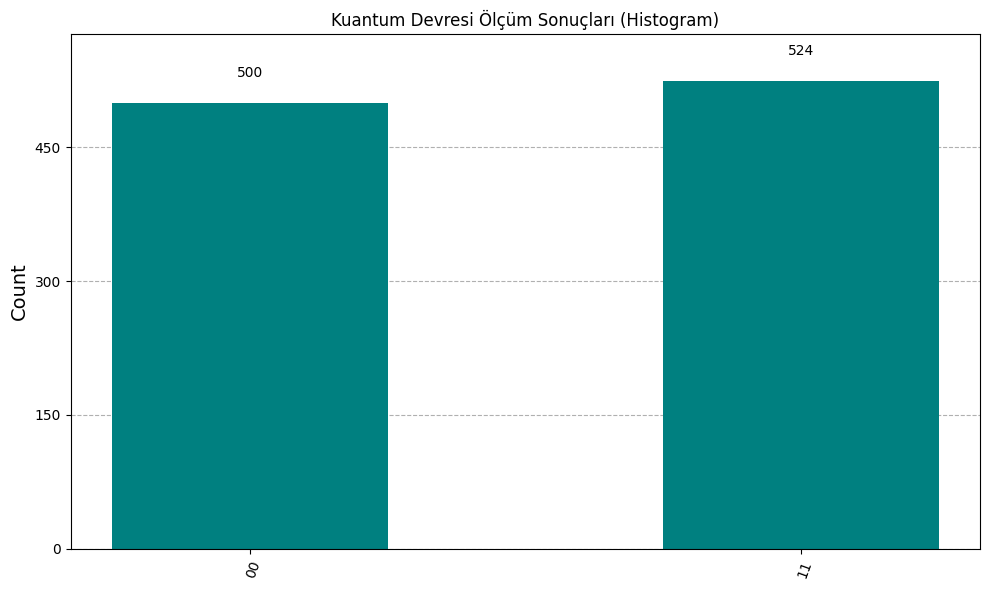

In [ ]:
# Jupyter'in grafikleri hücre altında göstermesini sağlar
%matplotlib inline

from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Örnek sim_counts verisi
sim_counts = {'00': 500, '11': 524}

# Kuantum simülatörü/donanımı ölçüm sonuçlarını görselleştirme
fig = plot_histogram(
    sim_counts,
    title="Kuantum Devresi Ölçüm Sonuçları (Histogram)",
    figsize=(10, 6),
    color='teal'
)

# Qiskit plot_histogram bazen doğrudan fig nesnesi döndürür,
# grafik nesnesini açıkça ekrana çizdirme komutu:
display(fig)

# Alternatif olarak matplotlib gösterimi
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')